In [1]:
import pandas as pd

# Load the CSV file for Nigeria
df = pd.read_csv(r"D:\Aman\KAIM-9\Week-0\Week0-climate-challange\climate-challenge-week0\data\nigeria.csv")

# Add a Country column
df["Country"] = "Nigeria"

# Convert YEAR and DOY to a proper datetime column
df["Date"] = pd.to_datetime(df["YEAR"] * 1000 + df["DOY"], format="%Y%j")

# Extract Month as a separate column
df["Month"] = df["Date"].dt.month

df.head()

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Country,Date,Month
0,2015,1,25.23,29.25,22.06,7.19,0.0,68.26,1.73,2.61,100.86,13.36,Nigeria,2015-01-01,1
1,2015,2,26.16,29.41,22.87,6.54,0.0,73.23,1.42,1.95,100.94,15.37,Nigeria,2015-01-02,1
2,2015,3,25.66,29.02,22.63,6.39,0.0,78.71,1.69,2.33,101.06,15.98,Nigeria,2015-01-03,1
3,2015,4,24.11,27.27,19.92,7.35,0.0,63.66,2.15,3.80,101.09,11.65,Nigeria,2015-01-04,1
4,2015,5,23.40,27.28,18.18,9.10,0.0,59.45,1.88,3.48,101.03,10.40,Nigeria,2015-01-05,1


In [2]:
import numpy as np

# Replace all -999 with np.nan
df = df.replace(-999, np.nan)

# Check for duplicates
duplicates = df.duplicated().sum()
print(f"Number of duplicate rows: {duplicates}")

# Drop duplicates if any
if duplicates > 0:
    df = df.drop_duplicates()
    print(f"Duplicates removed. New shape: {df.shape}")

Number of duplicate rows: 0


In [3]:
# Run df.describe() on all numeric columns
df.describe()

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Date,Month
count,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108,4108.000000
mean,2020.131451,180.121227,26.656928,28.914667,24.886461,4.028206,4.213914,85.237040,2.217135,2.903335,100.827205,18.558505,2020-08-15 12:00:00,6.423564
min,2015.000000,1.000000,21.120000,25.260000,15.170000,1.160000,0.000000,54.400000,0.740000,1.290000,100.380000,9.430000,2015-01-01 00:00:00,1.000000
25%,2017.000000,86.000000,25.720000,27.920000,24.100000,3.090000,0.330000,83.930000,1.770000,2.370000,100.710000,17.970000,2017-10-23 18:00:00,3.000000
50%,2020.000000,179.000000,26.820000,28.990000,25.100000,3.770000,1.840000,86.350000,2.200000,2.810000,100.820000,18.840000,2020-08-15 12:00:00,6.000000
75%,2023.000000,272.000000,27.540000,29.910000,25.860000,4.600000,5.200000,88.500000,2.630000,3.390000,100.950000,19.570000,2023-06-08 06:00:00,9.000000
max,2026.000000,366.000000,29.290000,32.880000,27.790000,11.730000,166.100000,93.790000,4.780000,6.000000,101.350000,21.740000,2026-03-31 00:00:00,12.000000
std,3.248907,106.294767,1.123335,1.294345,1.396727,1.399169,7.266742,5.446007,0.587191,0.696885,0.165321,1.646313,NaN,3.477046


In [4]:
# Check missing values
missing = df.isna().sum()
missing_pct = (missing / len(df)) * 100

# Create a summary DataFrame
missing_summary = pd.DataFrame({
    'Missing Count': missing,
    'Missing %': missing_pct
})

# Filter columns with >5% missing
high_missing = missing_summary[missing_summary['Missing %'] > 5]
print("Columns with >5% missing values:")
print(high_missing)

# Show all missing values
print("\nAll columns with missing values:")
print(missing_summary[missing_summary['Missing Count'] > 0])

Columns with >5% missing values:
Empty DataFrame
Columns: [Missing Count, Missing %]
Index: []

All columns with missing values:
Empty DataFrame
Columns: [Missing Count, Missing %]
Index: []


In [5]:
from scipy.stats import zscore

cols = [
    "T2M",
    "T2M_MAX",
    "T2M_MIN",
    "PRECTOTCORR",
    "RH2M",
    "WS2M",
    "WS2M_MAX"
]

z_scores = np.abs(df[cols].apply(zscore))

outliers = (z_scores > 3).sum()
print(outliers)

T2M             10
T2M_MAX          1
T2M_MIN         68
PRECTOTCORR     75
RH2M           128
WS2M             5
WS2M_MAX        10
dtype: int64


<Axes: xlabel='Date'>

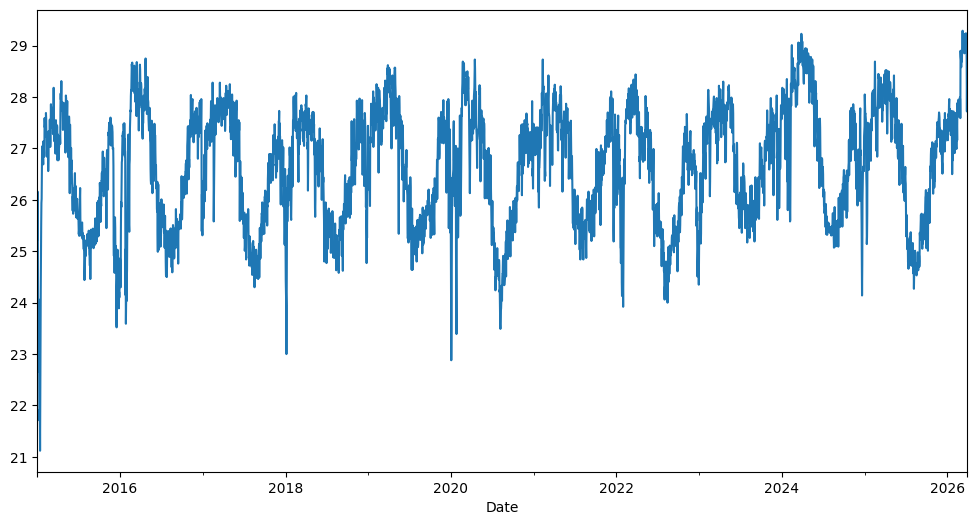

In [6]:
monthly_temp = df.groupby("Date")["T2M"].mean()

monthly_temp.plot(figsize=(12,6))

<Axes: xlabel='Month'>

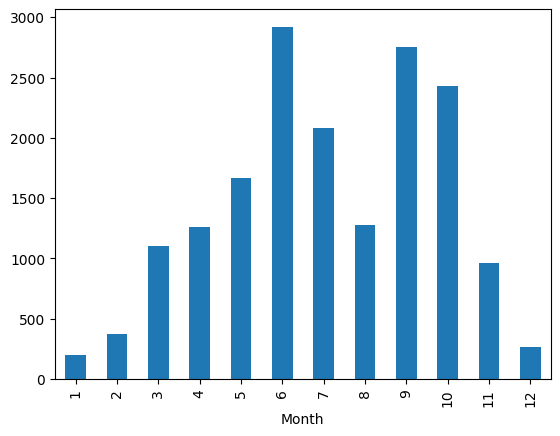

In [7]:
monthly_rain = df.groupby("Month")["PRECTOTCORR"].sum()

monthly_rain.plot(kind="bar")

<Axes: >

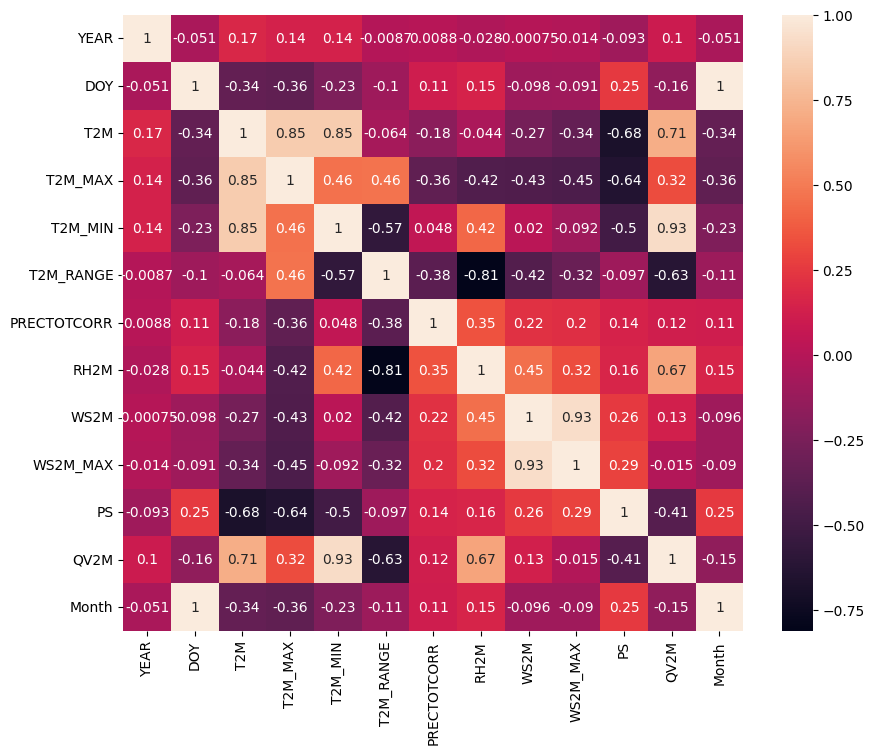

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,8))
sns.heatmap(df.corr(numeric_only=True), annot=True)

<Axes: xlabel='T2M', ylabel='RH2M'>

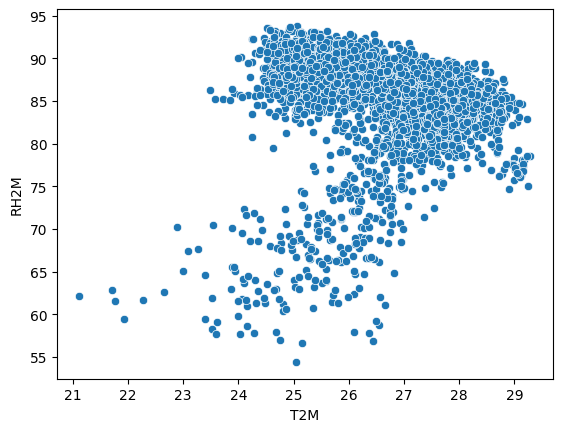

In [9]:
sns.scatterplot(data=df, x="T2M", y="RH2M")


<Axes: xlabel='T2M_RANGE', ylabel='WS2M'>

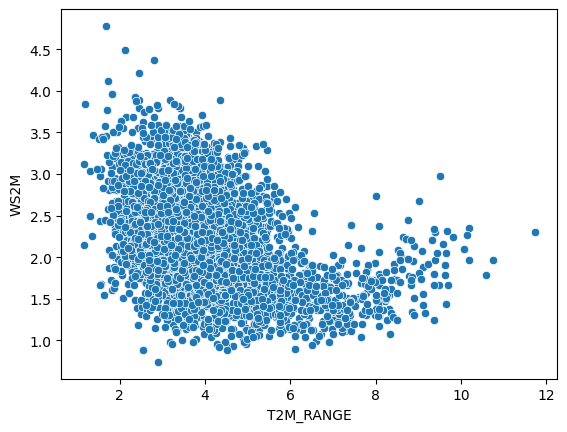

In [11]:
sns.scatterplot(data=df, x="T2M_RANGE", y="WS2M")

<Axes: xlabel='PRECTOTCORR', ylabel='Count'>

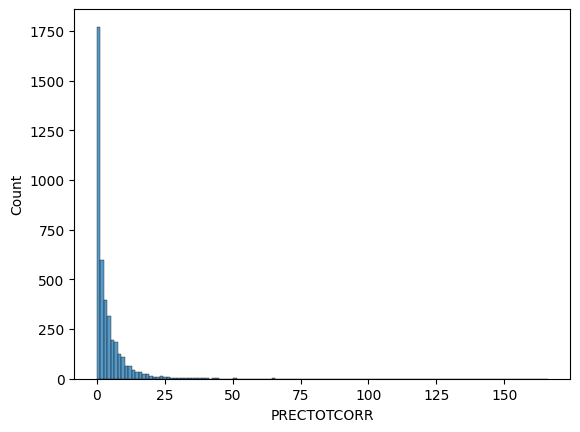

In [12]:
sns.histplot(df["PRECTOTCORR"])

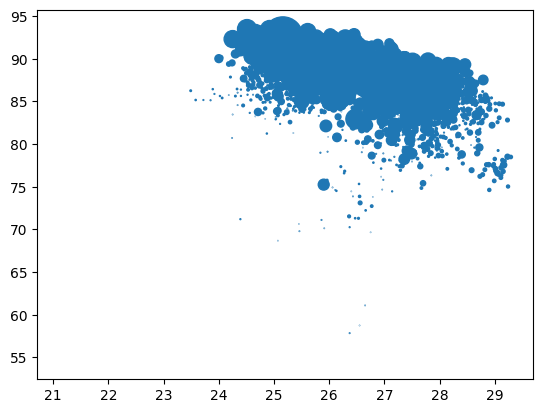

In [13]:
plt.scatter(
    df["T2M"],
    df["RH2M"],
    s=df["PRECTOTCORR"]*5
)

In [16]:
df.to_csv(r"D:\Aman\KAIM-9\Week-0\Week0-climate-challange\climate-challenge-week0\data\nigeria_clean.csv", index=False)